In [ ]:
Experiment No: 14

Title: GAN (Generative Adversarial Network)

Aim:

To implement a Generative Adversarial Network (GAN) and understand how a generator and discriminator work together to generate realistic data.

Procedure:

1.Import Libraries
Import TensorFlow, Keras, NumPy, and Matplotlib.

2.Load Dataset
Use a dataset like MNIST (handwritten digits).

3.Normalize Data
Scale images between -1 and 1.

4.Build Generator Model
Create a neural network that generates fake images from random noise.

5.Build Discriminator Model
Create a model that classifies images as real or fake.

6.Compile Discriminator
Use binary cross-entropy loss.

7.Combine GAN Model
Stack generator and discriminator.

8.Train GAN
Train discriminator on real + fake images
Train generator to fool discriminator

9.Generate Images
Use generator to create new images.

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py:86: UserWarning: The model does not have any trainable weights.
  warnings.warn("The model does not have any trainable weights.")


Epoch 0
Epoch 200
Epoch 400
Epoch 600
Epoch 800
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step


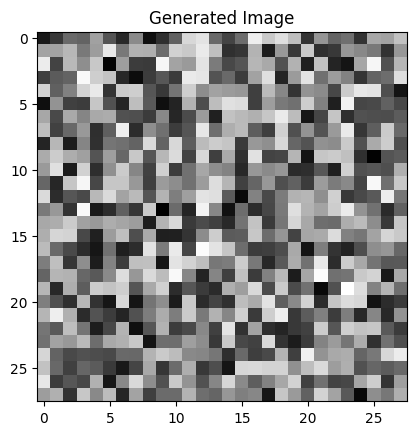

In [1]:
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# Load MNIST dataset
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()

# Normalize
x_train = (x_train - 127.5) / 127.5
x_train = x_train.reshape(x_train.shape[0], 28, 28, 1)

# Generator
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(128, activation='relu', input_dim=100),
        layers.Dense(784, activation='tanh'),
        layers.Reshape((28,28,1))
    ])
    return model

# Discriminator
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Flatten(input_shape=(28,28,1)),
        layers.Dense(128, activation='relu'),
        layers.Dense(1, activation='sigmoid')
    ])
    return model

generator = build_generator()
discriminator = build_discriminator()

discriminator.compile(optimizer='adam',
                      loss='binary_crossentropy',
                      metrics=['accuracy'])

# GAN model
discriminator.trainable = False

gan = tf.keras.Sequential([generator, discriminator])
gan.compile(optimizer='adam', loss='binary_crossentropy')

# Training
epochs = 1000
batch_size = 32

for epoch in range(epochs):
    # Train discriminator
    idx = np.random.randint(0, x_train.shape[0], batch_size)
    real_images = x_train[idx]

    noise = np.random.normal(0,1,(batch_size,100))
    fake_images = generator.predict(noise, verbose=0)

    d_loss_real = discriminator.train_on_batch(real_images, np.ones((batch_size,1)))
    d_loss_fake = discriminator.train_on_batch(fake_images, np.zeros((batch_size,1)))

    # Train generator
    noise = np.random.normal(0,1,(batch_size,100))
    g_loss = gan.train_on_batch(noise, np.ones((batch_size,1)))

    if epoch % 200 == 0:
        print(f"Epoch {epoch}")

# Generate image
noise = np.random.normal(0,1,(1,100))
generated_img = generator.predict(noise)

plt.imshow(generated_img[0].reshape(28,28), cmap='gray')
plt.title("Generated Image")
plt.show()

Result:

Successfully implemented a Generative Adversarial Network (GAN). The generator learned to create realistic images, while the discriminator improved in distinguishing real and fake data, demonstrating adversarial learning.